In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error

In [2]:
# --- 1. Carga y Preparación ---
try:
    datos = pd.read_csv('Datasets/accesos_agrupados.csv', sep=',')
    print("Paso 1: Archivo 'accesos_agrupados.csv' cargado.")
except FileNotFoundError:
    print("Error: No se encontró el archivo.")
    exit()

try:
    vacaciones = pd.read_csv('Datasets/dias_vacaciones.txt', header=None, names=['Fecha'])
    vacaciones['Fecha'] = pd.to_datetime(vacaciones['Fecha'])
    dias_vacaciones = set(vacaciones['Fecha'])
    datos['vacaciones'] = datos.index.isin(dias_vacaciones).astype(int)
    print("Archivo Días de Vacaciones cargado con éxito.")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'dias_vacaciones.txt'.")
    exit()

try:
    datos['Fecha'] = pd.to_datetime(datos['Fecha'])
    datos = datos.set_index('Fecha').sort_index()
    print("Paso 2: Columna de fecha procesada y establecida como índice.")
except KeyError:
    print("Error: No se encontró la columna 'Fecha'. Columnas detectadas:", datos.columns)
    exit()

Paso 1: Archivo 'accesos_agrupados.csv' cargado.
Archivo Días de Vacaciones cargado con éxito.
Paso 2: Columna de fecha procesada y establecida como índice.


In [3]:
# --- 2. Ingeniería de Características ---

TARGET = 'Accesos'

COLUMNAS_A_EXCLUIR_DE_FEATURES = [TARGET, 'Día de la Semana']

try:
    datos = pd.get_dummies(datos, columns=['Número Semestre'], prefix='Semestre', drop_first=True)
except KeyError:
    print("Error: No se encontró la columna 'Número Semestre'. Revisa los nombres de columna:")
    print(datos.columns)
    exit()

if TARGET not in datos.columns:
    print(f"Error Crítico: La columna objetivo '{TARGET}' no se encuentra en el dataset.")
    print("Columnas disponibles:", datos.columns)
    exit()

#for lag in [7, 14, 30, 90, 180]:
#    datos[f'lag_{lag}_dias'] = datos[TARGET].shift(lag)
#for window in [7, 30, 90]:
#    datos[f'media_movil_{window}d'] = datos[TARGET].shift(1).rolling(window=window).mean()
#datos['ewma_30d'] = datos[TARGET].shift(1).ewm(span=7, adjust=False).mean()

datos['mes_sin'] = np.sin(2 * np.pi * datos.index.month / 12)
datos['mes_cos'] = np.cos(2 * np.pi * datos.index.month / 12)
datos['dia_semana_sin'] = np.sin(2 * np.pi * datos.index.dayofweek / 7)
datos['dia_semana_cos'] = np.cos(2 * np.pi * datos.index.dayofweek / 7)

datos = datos.dropna()
print("Paso 3: Ingeniería de características completada.")

Paso 3: Ingeniería de características completada.


In [5]:
# --- 3. División de Datos ---
FEATURES = [col for col in datos.columns if col not in COLUMNAS_A_EXCLUIR_DE_FEATURES]
X = datos[FEATURES]
y = datos[TARGET]
test_percentage = 0.10
test_size = int(len(datos) * test_percentage)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

In [6]:
# --- 4. DATA AUGMENTATION ---
print("Paso 4: Realizando Aumento de Datos...")
X_train_aug = [X_train.copy()]
y_train_aug = [y_train.copy()]
N_AUGMENTATIONS = 4
for i in range(N_AUGMENTATIONS):
    X_new = X_train.copy()
    if i % 2 == 0:
        y_new = y_train * np.random.uniform(0.95, 1.05)
    else:
        y_new = y_train + np.random.normal(0, y_train.std() * 0.02, len(y_train))
    df_new = X_new.copy()
    df_new[TARGET] = y_new
    #for lag in [7, 14, 30]:
    #    df_new[f'lag_{lag}_dias'] = df_new[TARGET].shift(lag)
    #for window in [7, 30, 90]:
    #    df_new[f'media_movil_{window}d'] = df_new[TARGET].shift(1).rolling(window=window).mean()
    #df_new['ewma_30d'] = df_new[TARGET].shift(1).ewm(span=7, adjust=False).mean()
    df_new = df_new.dropna()
    X_train_aug.append(df_new[FEATURES])
    y_train_aug.append(df_new[TARGET])
X_train_final = pd.concat(X_train_aug)
y_train_final = pd.concat(y_train_aug)
print(f"-> Tamaño final del set de entrenamiento: {len(X_train_final)} muestras.")

Paso 4: Realizando Aumento de Datos...
-> Tamaño final del set de entrenamiento: 1505 muestras.


In [7]:
# --- 5. Ajuste de Hiperparámetros ---
print("Paso 5: Iniciando búsqueda de hiperparámetros...")
tscv = TimeSeriesSplit(n_splits=5)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.1],
    'subsample': [0.8, 1],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0.5, 1, 2]
}
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=tscv, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"-> Mejores parámetros encontrados: {grid_search.best_params_}")

Paso 5: Iniciando búsqueda de hiperparámetros...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
-> Mejores parámetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.8}


In [8]:
# --- 6. Entrenamiento y Evaluación Final ---
print("Paso 6: Entrenando modelo final y evaluando...")
best_model = xgb.XGBRegressor(**grid_search.best_params_, objective='reg:squarederror', random_state=42)
best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = best_model.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = np.mean(np.abs(y_test - predictions))
print(f"\nRESULTADOS EN CONJUNTO DE PRUEBA:")
print(f"-> MSE: {mse:.2f}")
print(f"-> MAE: {mae:.2f}")
print(f"-> RMSE: {rmse:.2f}")
print(f"-> R²: {r2:.2f}")

Paso 6: Entrenando modelo final y evaluando...

RESULTADOS EN CONJUNTO DE PRUEBA:
-> MSE: 657618.72
-> MAE: 578.70
-> RMSE: 810.94
-> R²: 0.62


Paso 7: Generando visualización de resultados...


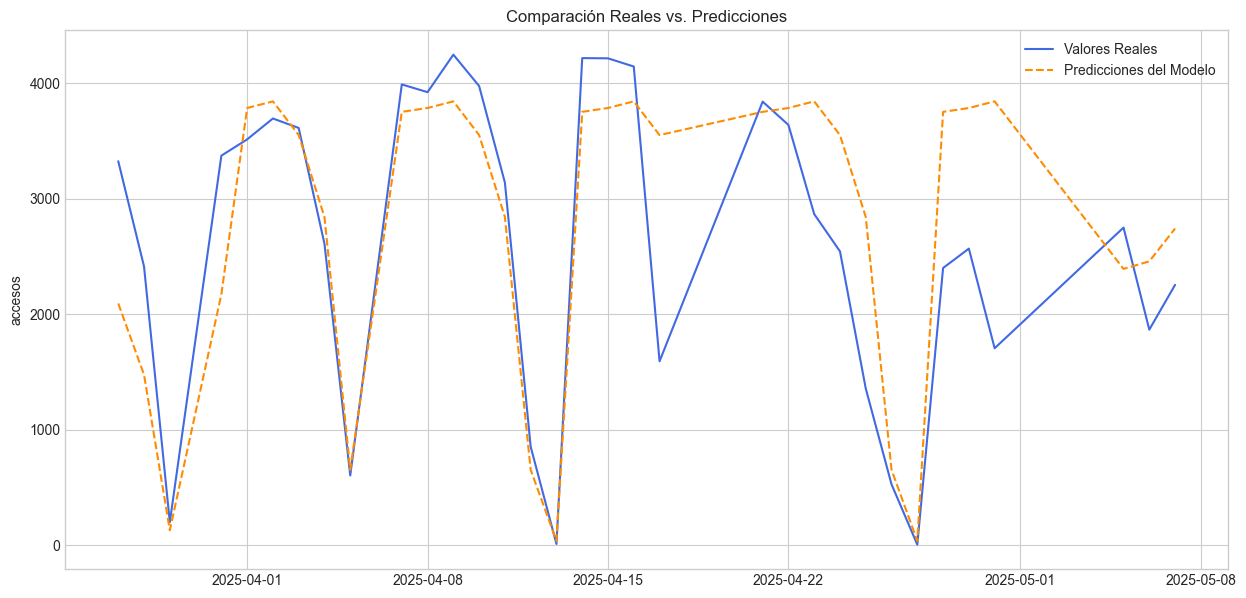

In [9]:
# --- 7. Visualización ---
print("Paso 7: Generando visualización de resultados...")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Valores Reales', color='royalblue')
plt.plot(y_test.index, predictions, label='Predicciones del Modelo', color='darkorange', linestyle='--')
plt.title('Comparación Reales vs. Predicciones')
plt.ylabel('accesos') 
plt.legend()
plt.show()

Paso 7: Generando visualización de resultados...


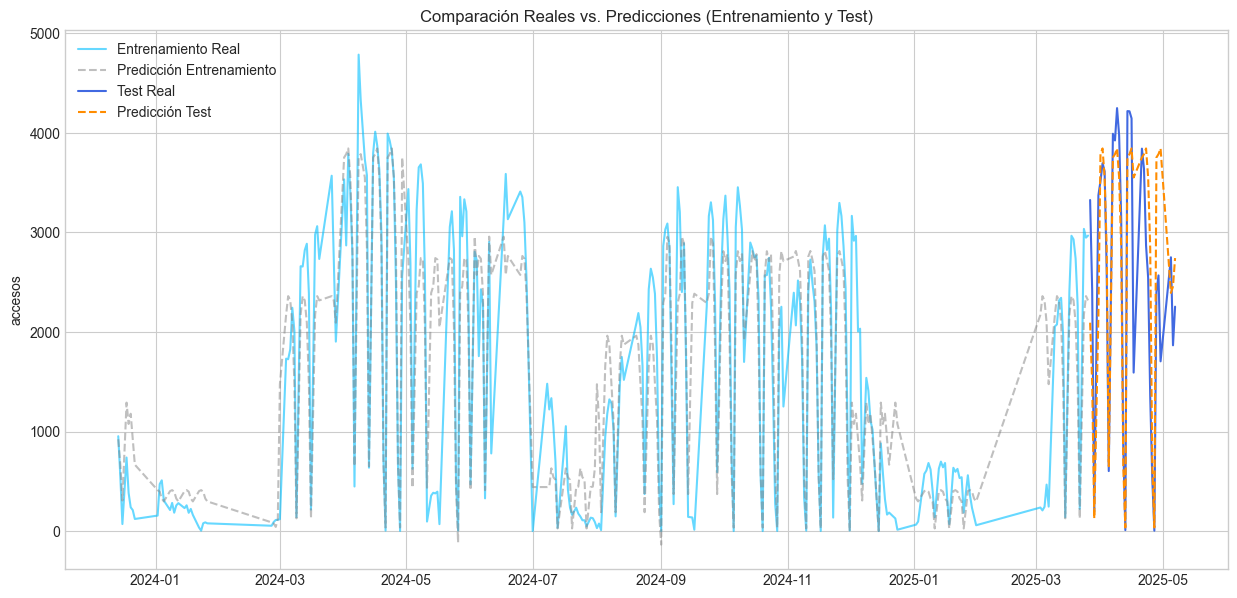

In [10]:
print("Paso 7: Generando visualización de resultados...")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))

train_predictions = best_model.predict(X_train)

plt.plot(y_train.index, y_train, label='Entrenamiento Real', color='deepskyblue', alpha=0.6)
plt.plot(y_train.index, train_predictions, label='Predicción Entrenamiento', color='gray', linestyle='--', alpha=0.5)
plt.plot(y_test.index, y_test, label='Test Real', color='royalblue')
plt.plot(y_test.index, predictions, label='Predicción Test', color='darkorange', linestyle='--')

plt.title('Comparación Reales vs. Predicciones (Entrenamiento y Test)')
plt.ylabel('accesos')
plt.legend()
plt.show()

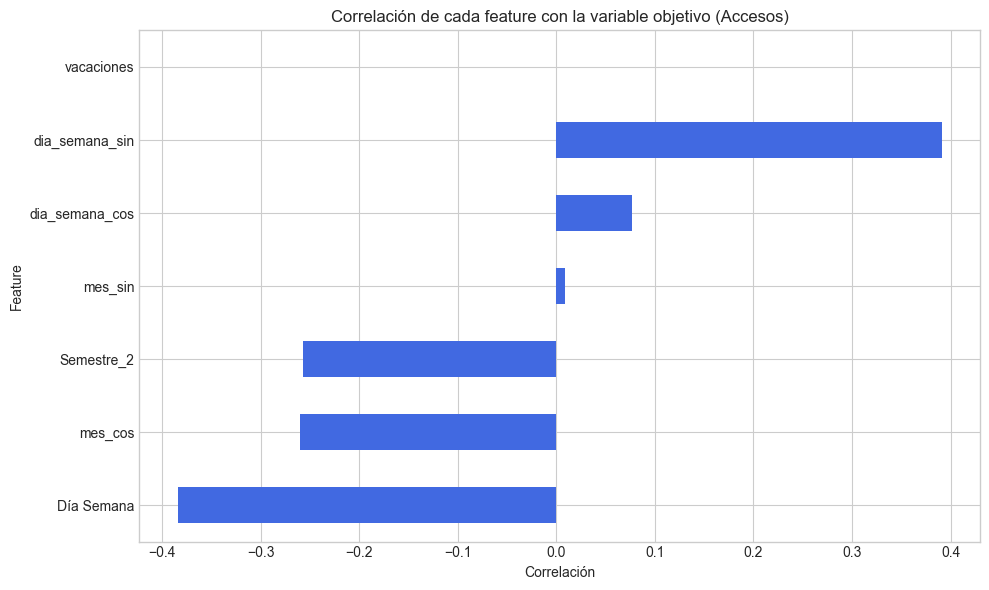

In [11]:
corr_matrix = X_train_final.copy()
corr_matrix['Accesos'] = y_train_final
corr = corr_matrix.corr()

target_corr = corr['Accesos'].drop('Accesos')

plt.figure(figsize=(10, 6))
target_corr.sort_values().plot(kind='barh', color='royalblue')
plt.title('Correlación de cada feature con la variable objetivo (Accesos)')
plt.xlabel('Correlación')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()